<a href="https://colab.research.google.com/github/dee431/-Diamond-Price-Prediction/blob/main/%F0%9F%92%8E%F0%9F%92%8E%F0%9F%92%8E%F0%9F%92%8E%F0%9F%92%8E%F0%9F%92%8EDiamond_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Linear Regression Model training on diamond dataset:**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import sklearn
import seaborn as sns

# **Load Dataset**

In [4]:
df = pd.read_csv("/content/diamonds.csv")

# **Analysis of Dataset**

In [5]:
df.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [6]:
df.tail()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
53935,53936,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,53937,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,53938,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,53939,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74
53939,53940,0.75,Ideal,D,SI2,62.2,55.0,2757,5.83,5.87,3.64


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  object 
 3   color       53940 non-null  object 
 4   clarity     53940 non-null  object 
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.5+ MB


In [8]:
df.describe()

,Unnamed: 0,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,26970.500000,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,15571.281097,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,1.000000,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,13485.750000,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,26970.500000,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,40455.250000,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,53940.000000,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [9]:
df.isnull().sum()

,0
Unnamed: 0,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
price,0
x,0
y,0


In [10]:
df = df.drop(['Unnamed: 0'], axis=1)

In [11]:
df = df.rename(columns = {"depth":"total depth %","x":"length", "y":"width", "z":"depth"})

In [12]:
df.head()

,carat,cut,color,clarity,total depth %,table,price,length,width,depth
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


# **Analyse the data via data visualization:**

In [13]:
def hisplot(features):
  sns.histplot(features, kde=False)
  plt.show()

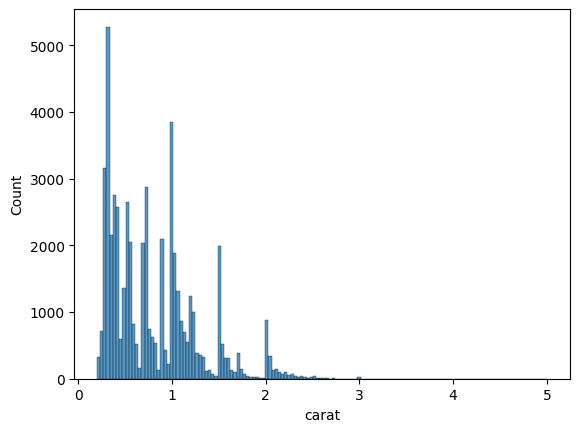

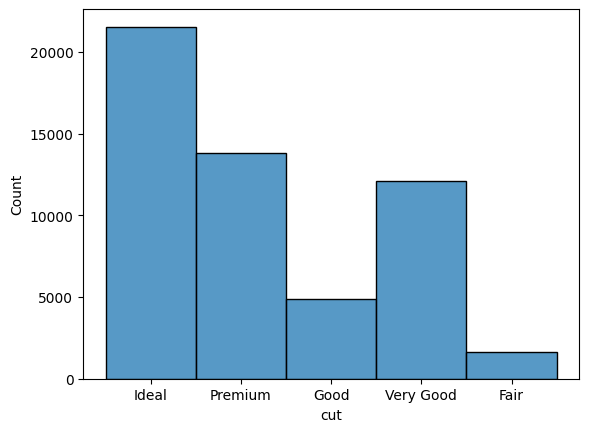

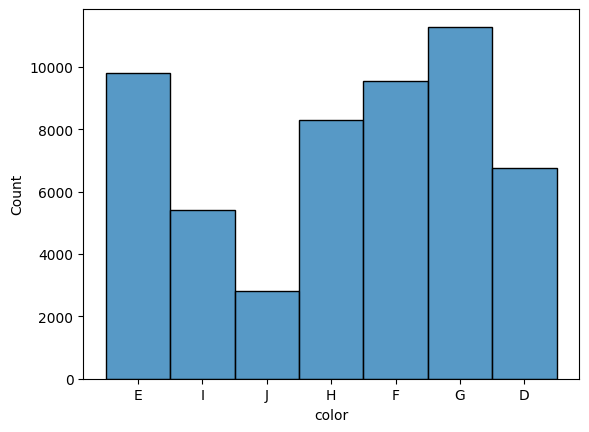

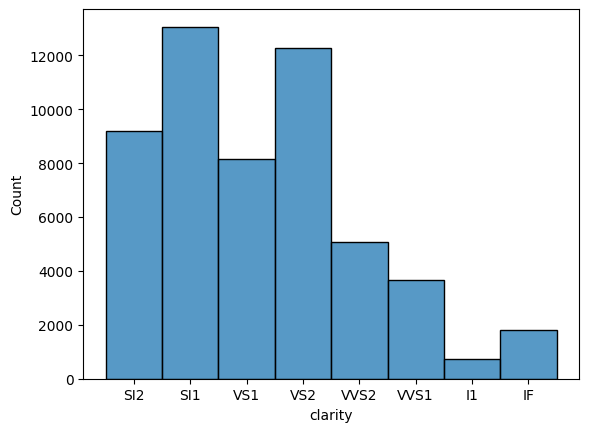

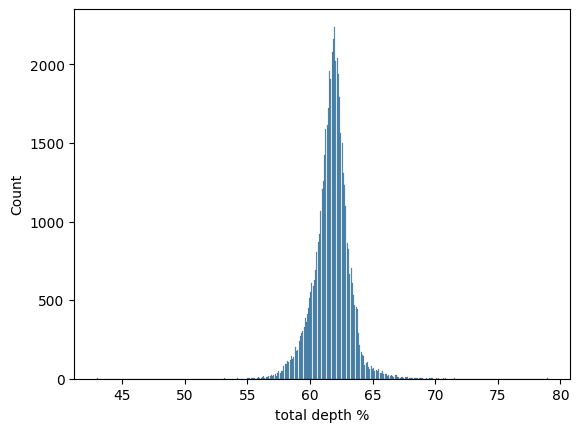

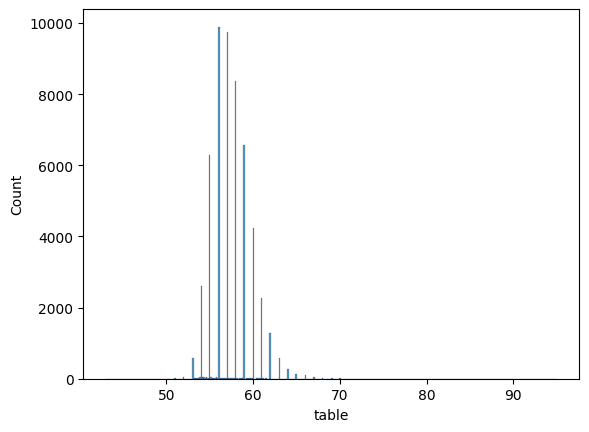

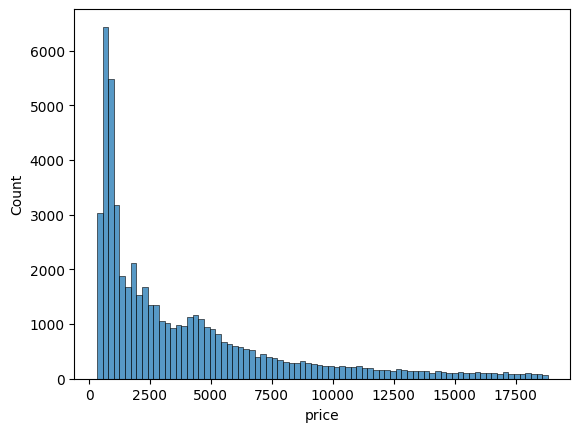

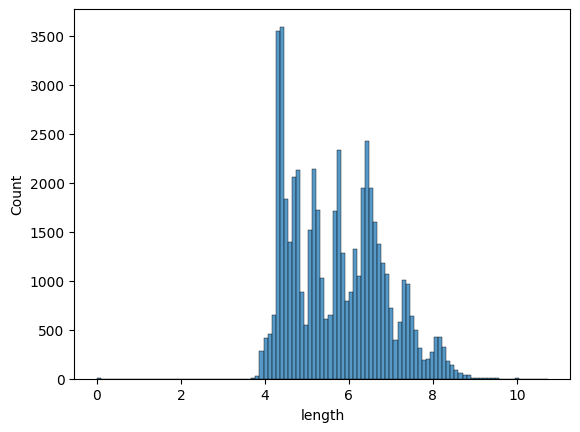

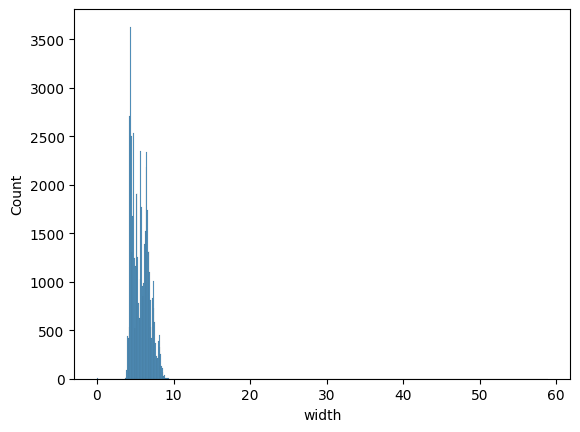

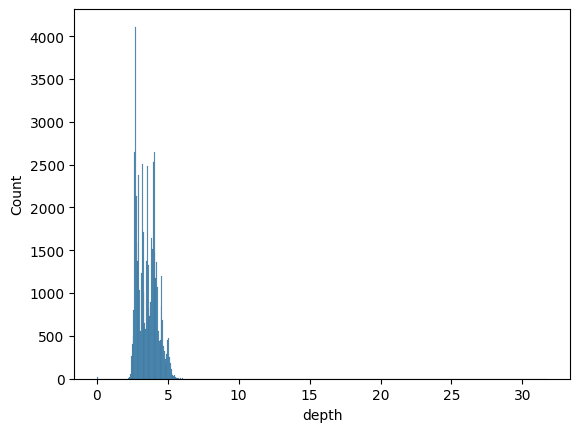

In [14]:
for column in df.columns:
  hisplot(df[column])

In [15]:
df['clarity'].value_counts()

,count
clarity,
SI1,13065
VS2,12258
SI2,9194
VS1,8171
VVS2,5066
VVS1,3655
IF,1790
I1,741


In [16]:
df['cut'].value_counts()

,count
cut,
Ideal,21551
Premium,13791
Very Good,12082
Good,4906
Fair,1610


In [17]:
df['color'].value_counts()

,count
color,
G,11292
E,9797
F,9542
H,8304
D,6775
I,5422
J,2808


In [18]:
df['cut'].value_counts()

,count
cut,
Ideal,21551
Premium,13791
Very Good,12082
Good,4906
Fair,1610


# **One Hot Encoding**

In [19]:
clarity = pd.get_dummies(df['clarity'], drop_first = True)#drop a column to multicollinearity
color = pd.get_dummies(df['color'], drop_first = True)

# **Ordinal Encoding:**

In [20]:
from sklearn.preprocessing import OrdinalEncoder

ord_e = OrdinalEncoder(categories=[['Ideal', 'Premium', 'Very Good', 'Good', 'Fair']])
df['cut'] = ord_e.fit_transform(df[['cut']])

In [21]:
df.drop(['clarity', 'color'], axis = 1, inplace=True)

# **After convert the categorical data to numeric form let's concate these feature with dataframe:**

In [22]:
df = pd.concat([df, clarity, color], axis=1)

In [23]:
df.head()

,carat,cut,total depth %,table,price,length,width,depth,IF,SI1,...,VS1,VS2,VVS1,VVS2,E,F,G,H,I,J
0,0.23,0.0,61.5,55.0,326,3.95,3.98,2.43,False,False,...,False,False,False,False,True,False,False,False,False,False
1,0.21,1.0,59.8,61.0,326,3.89,3.84,2.31,False,True,...,False,False,False,False,True,False,False,False,False,False
2,0.23,3.0,56.9,65.0,327,4.05,4.07,2.31,False,False,...,True,False,False,False,True,False,False,False,False,False
3,0.29,1.0,62.4,58.0,334,4.20,4.23,2.63,False,False,...,False,True,False,False,False,False,False,False,True,False
4,0.31,3.0,63.3,58.0,335,4.34,4.35,2.75,False,False,...,False,False,False,False,False,False,False,False,False,True


# **Correlation between the features**

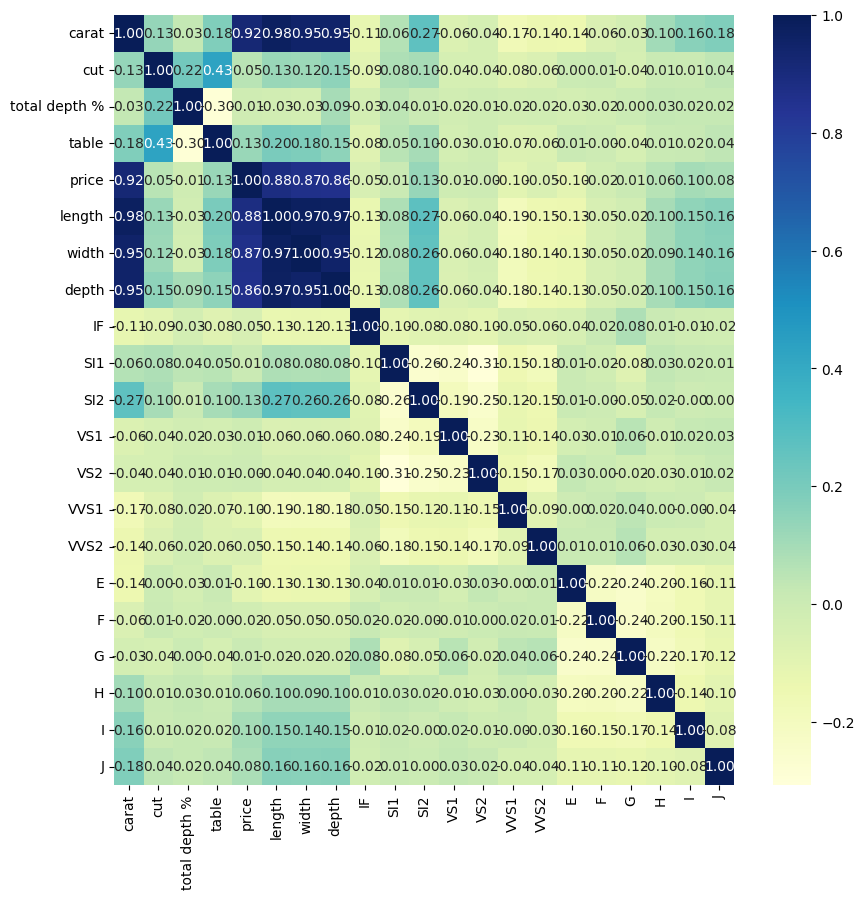

In [24]:
plt.subplots(figsize=(10,10))
sns.heatmap(df.corr(), cmap="YlGnBu", annot=True, fmt=".2f")
plt.show()

# **Drop duplicate rows**

In [25]:
df.drop_duplicates(inplace=True)

# **Split dependent and independant features:**

In [26]:
x = df.drop('price', axis=1)

y = df['price']

# **Normalization:**

In [27]:
from sklearn import preprocessing

preprocess = preprocessing.StandardScaler()

x_transform = preprocess.fit_transform(x)

y_reshape = np.array(y).reshape(-1, 1)
y_transform = preprocess.fit_transform(y_reshape)

# **Splitting the training and testing data**

In [28]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x_transform, y_transform, test_size=.20, random_state = 101)

# **Linear Regression:**

In [29]:
from sklearn.linear_model import LinearRegression

linearReg = LinearRegression()

linearReg.fit(x_train, y_train)

LinearRegression()

# **Model Evaluation:**

In [30]:
from sklearn.metrics import r2_score, mean_squared_error
# prediction
y_predicted = linearReg.predict(x_test)

# Calculate accuracy:
accuracy = r2_score(y_test, y_predicted)*100

# Mean Squared error:
mse = mean_squared_error(y_test, y_predicted)

# Root mean square:
rmse = np.sqrt(mse)

print("Linear Regression:\n", "--"*30)
print("Mean Squared Error: ", mse)
print("Root Mean Squared Error: ", rmse)
print("Accurcay: ", accuracy)

Linear Regression:
 ------------------------------------------------------------
Mean Squared Error:  0.07987053016353025
Root Mean Squared Error:  0.28261374730102967
Accurcay:  91.8629741336772
